# 머신러닝 실습 - 자전거 데이터 분석  

목표: 현재 데이터 컬럼을 기반으로, 자전거 총 대여수(count)를 예측하는 모델 작성

## 모듈 임포트

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## 데이터프레임 불러오기

train_df = 훈련에 사용할 데이터프레임   
test_df = 데이터를 훈련시키고, 결과값인 count를 예측할 데이터프레임  

In [19]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [20]:
test_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


## EDA 및 데이터 전처리

### 목표      
1. 데이터의 분포 여부 파악 - 좌편향, 우편향, 정규분포  
2. 데이터 타입에 관한 재분류  
- 범주형으로 나타낼 수 있는 수치형은 범주형으로 변환   
- 날자형 데이터는 datetime으로 변환 / 시간, 요일, 월, 연도 등 필요한 정보를 추출  
3. 전처리가 필요한 변수 판별  
- 결측치/중복치/이상치 발견 시 처리    
- 스케일링/인코딩이 필요한 변수 판별    
4. 입력 변수, 결과 변수 선정  
- 히트맵을 통한 상관관계 분석으로 다중공선성 발생이 가능한 변수는 제외   
- 명백하게 의미가 없어보이는 변수는 미리 제거   

### EDA 및 데이터 전처리 결과 요약    

#### 1. 데이터 분류  
- **1-1. 입력 변수**   
    - 숫자형: temp, atemp, humidity, windspeed  
    - 범주형: season, holiday, workingday, weather    
    - 날자형: datetime
    - datetime 파생변수(숫자형)- year, month, weekofdays, hour   
- **1-2. 결과 변수**   
    - 통합 수행 시: **casual**  
    - 분리 모델로 수행시: **casual, registered**  

#### 2. 전처리 수행  
- **2-1. 타입 재분류**   
    - 숫자형에서 범주형으로: season, holiday, workingday, weather   
    - 문자열에서 날자형으로: datetime  
    - 날자형 분리 작업: year, month, weekofdays, hour   
- **2.2. 결측치: 없음**  

#### 3. 입력 변수
- 숫자형: temp, atemp, humidity, windspeed  
- 범주형: season, holiday, workingday, weather   
- 날자형: datetime  

#### 4. 결과 변수
- 후보  
    - **count**: 모델에 직접 count값을 학습시키는 케이스  
    - **casual, registered**: 우리의 목표값인 count가 casual+registered이므로, 두 변수를 분리해서 학습시키는 케이스    
- 두 경우를 분리해서 진행하고 양자간의 성능 비교를 통해 최적의 모델 도출

### 1. 초기 탐색

#### 목표    
- 각 컬럼의 타입 / 결측값 / 고유값 수 파악  
- 히스토그램을 통해서 데이터의 분포(좌편향, 우편향 등) 파악
- 타입 재분류가 필요한 데이터 확인
- 히트맵을 통해서 상관관계를 파악

#### 1-1. Info, Describe 관찰 결과
- **결측치**: train, test 데이터프레임 둘 모두 없음  
- **숫자형**: season, holiday, workingday, weather, temp, atemp, humidity, windspeed, registered, count  
- **범주형**: X  
- **날자형**: datetime   
- **컬럼 총 개수**: 10886개  

##### 인사이트
- season, holiday, workingday, weather 등의 변수는 이름도 그렇고, 데이터 통계도 그렇고 범주형으로 전환하는게 적절해 보임 
- datetime 데이터를 보아, 데이터는 1시간별로 집계된 것임을 알 수 있음. 날자형 데이터를 연도, 월, 요일, 시간 등의 파생 변수로 분리할 것 
- 요일별 count 분포나 시간별 예약건수(주간, 야간) 등이 주요 요인이 될 것으로 추정

In [21]:
train_df.info()
test_df.info()
train_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null   str    
 1   season      6493 non-null   int64  
 2   hol

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [22]:
train_df['datetime'] = pd.to_datetime(train_df['datetime'])
test_df['datetime'] = pd.to_datetime(test_df['datetime'])

train_df.info()
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(8)
memory usage: 1020.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------    

#### 1-2. 히스토그램 관찰 결과

**1. 수치형이 아닌 범주형으로 보이는 변수 발견**
- season, holiday, workingday, weather

**2. 각 변수별 의미**
- season: 1(봄), 2(여름), 3(가을), 4(겨울)
- holiday: 0(평일), 1(공휴일)
- workingday: 0(주말/휴일), 1(근무일)
- weather: 1(맑음), 2(구름낌/안개), 3(약간의 비/눈), 4(폭우/폭설)

**3. 데이터 분포 분석**
- 3-1. 수치형
    - 우편향: casual, registered, count, windspeed
    - 편향 거의 없음: temp, atemp, humidity
- 3-2. 범주형 
    - weather: 계절 정보는 균등하게 있음  
    - holiday: 평일 데이터가 공휴일 데이터보다 많음  
    - workingday: 근무일 데이터. holiday와 다르게 주말/휴일 둘다 포함이라 주말/휴일 데이터가 좀더 많아 보임    
    - weather: 날자가 1 -> 2 -> 3 -> 4로 감에 따라 데이터가 2배 이상씩 줄고 있음   

##### 인사이트 
- windspeed가 0인 날이 결측값인지, 실제 무풍인 날이었을지 모르겠음  

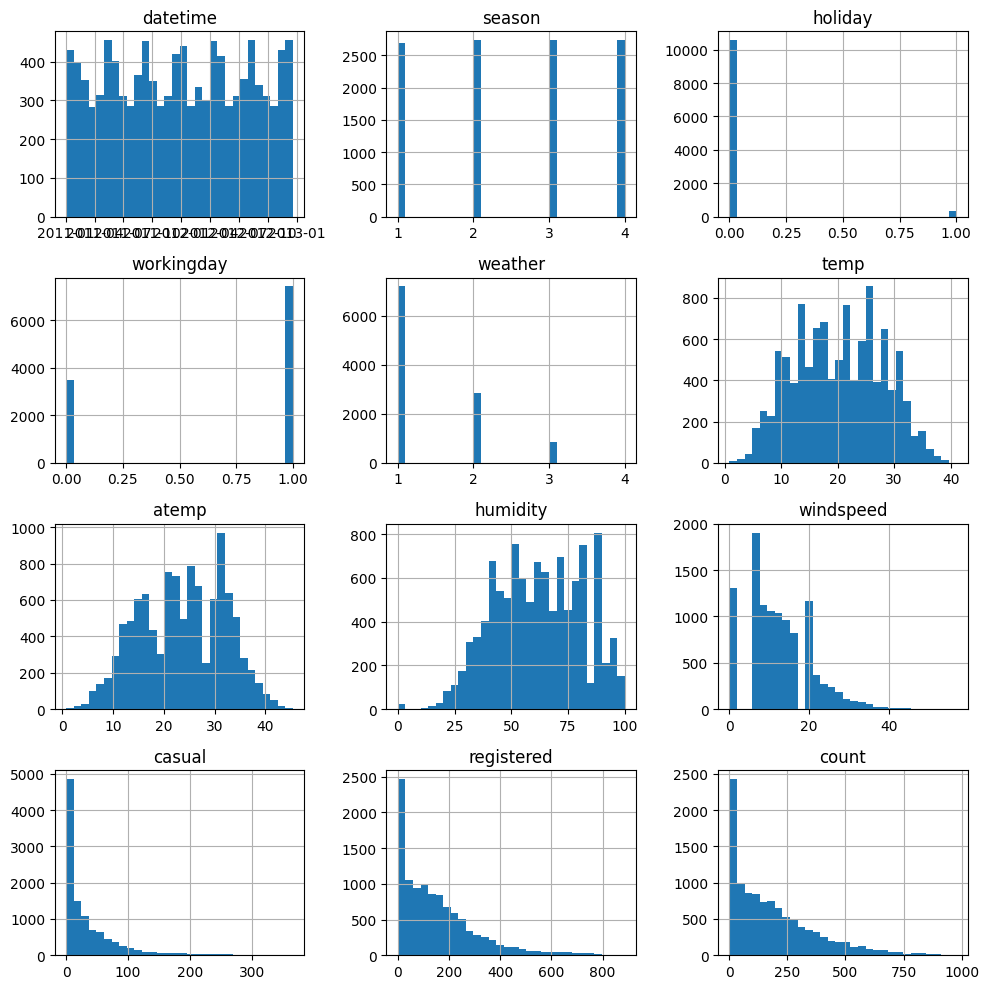

In [24]:
train_df.hist(bins=30, figsize=(10, 10))
plt.tight_layout()
plt.show()

#### 1-3. BoxPlot 관찰 결과  


#### 1-4. 상관관계 히트맵 관찰 결과


### 2. 타입 재분류 
#### 목표    
- 초기 탐색에서 얻은 Data를 기반으로 타입 재분류 수행 
    - 숫자형에서 범주형으로: season, holiday, workingday, weather   
    - 문자열에서 날자형으로: datetime  
    - 날자형 분리 작업: year, month, weekofdays, hour   
- 재분류 이후 바뀐 변수만 모아서 분포 확인 
    - 여기서는 year, month, weekofdays, hour 등이 됨 

### 3. 데이터 전처리 
#### 목표


### 4. 입력 변수, 결과 변수 선정 

